In [ ]:
"""
Let's try something interesting tonight
"""

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("data/housing.csv")

In [22]:
data.dropna(inplace=True)
data.info()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [13]:
from sklearn.model_selection import train_test_split

X = data.drop(['median_house_value'], axis=1)
y = data ['median_house_value']

In [14]:
#Le test_size c'est pour dire que 20% des données seront utilisées pour le test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

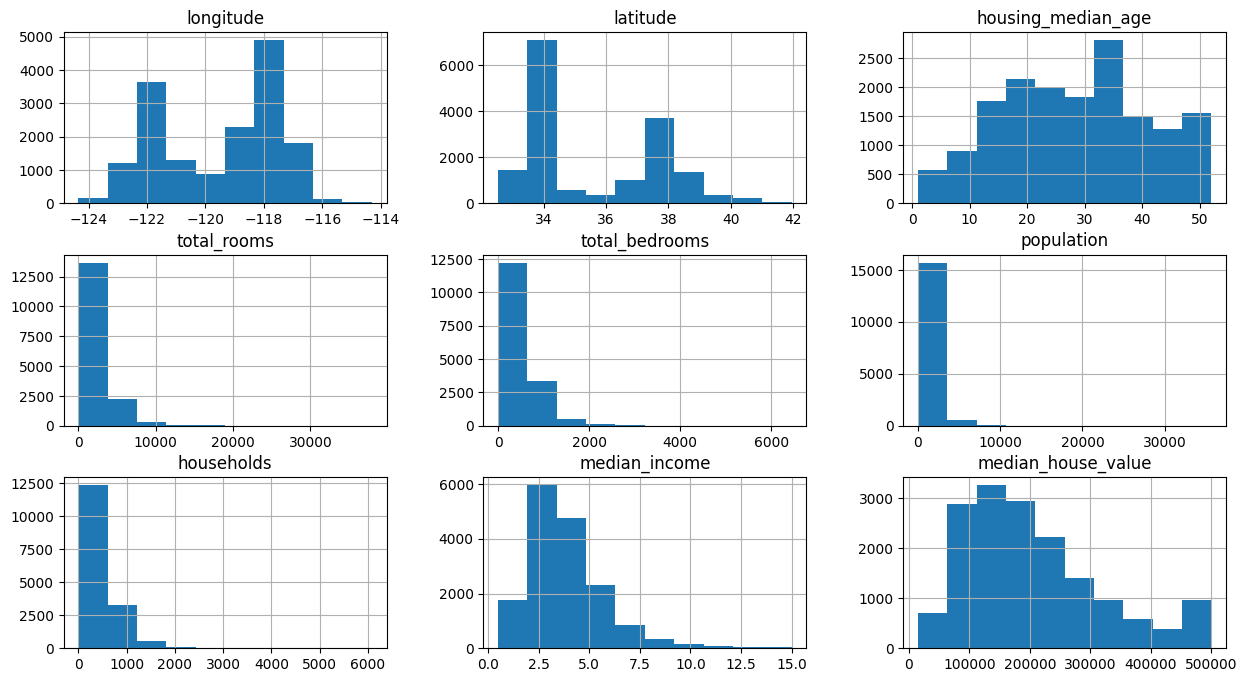

In [21]:
train_data = X_train.join(y_train)

train_data.hist(figsize=(15, 8))

<Axes: >

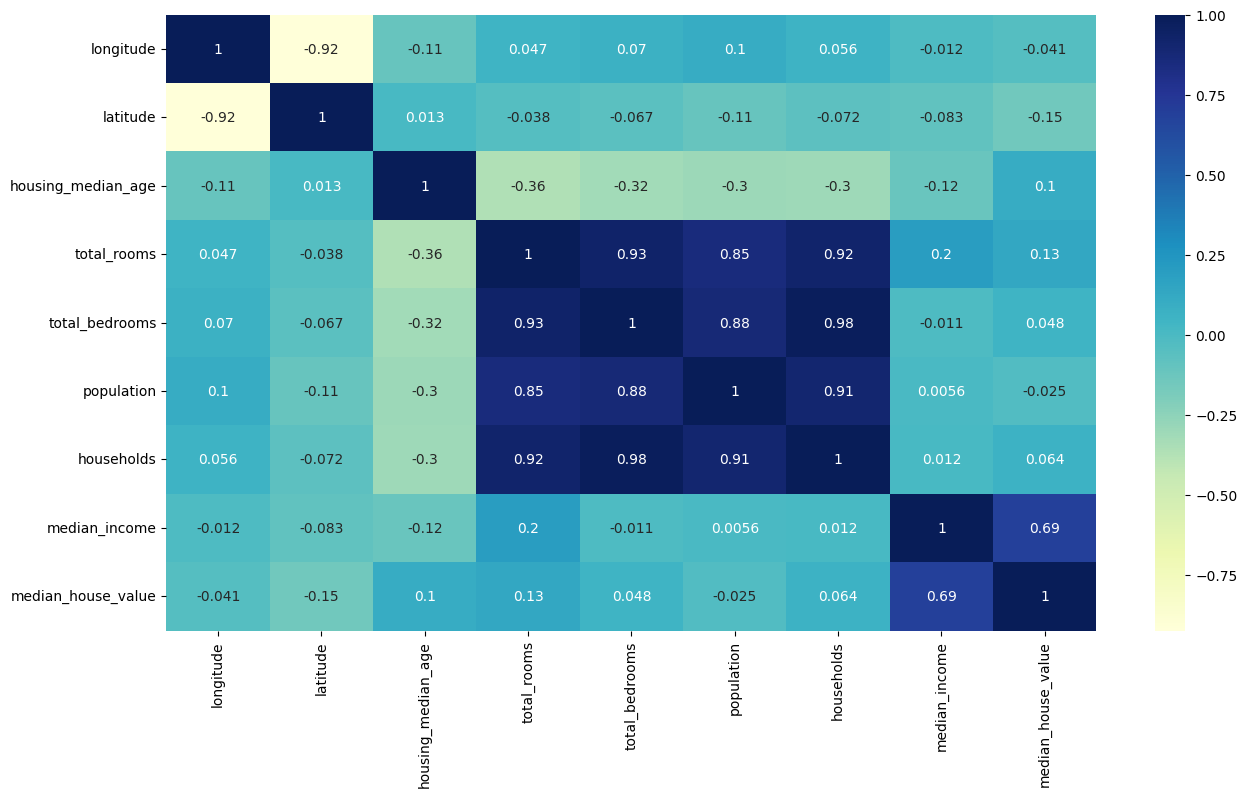

In [26]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [ ]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

In [39]:
"""get_dummies permet de transformer les variables texte en variables numériques
Si mon dataset était comme ceci: 
| id | color |
| -- | ----- |
| 1  | red   |
| 2  | blue  |
| 3  | green |

 data = pd.get_dummies(data, columns=['color']) ceci le transforme en ça
| id | color_blue | color_green | color_red |
| -- | ---------- | ----------- | --------- |
| 1  | 0          | 0           | 1         |
| 2  | 1          | 0           | 0         |
| 3  | 0          | 1           | 0         |

Ceci pd.get_dummies(train_data.ocean_proximity) crée un nouveau dataframe avec seulement les colonnes encodées 
 j'ajoute dtype=int pour préciser que je veux 0/1 au lieu de false/true
"""
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)


<Axes: >

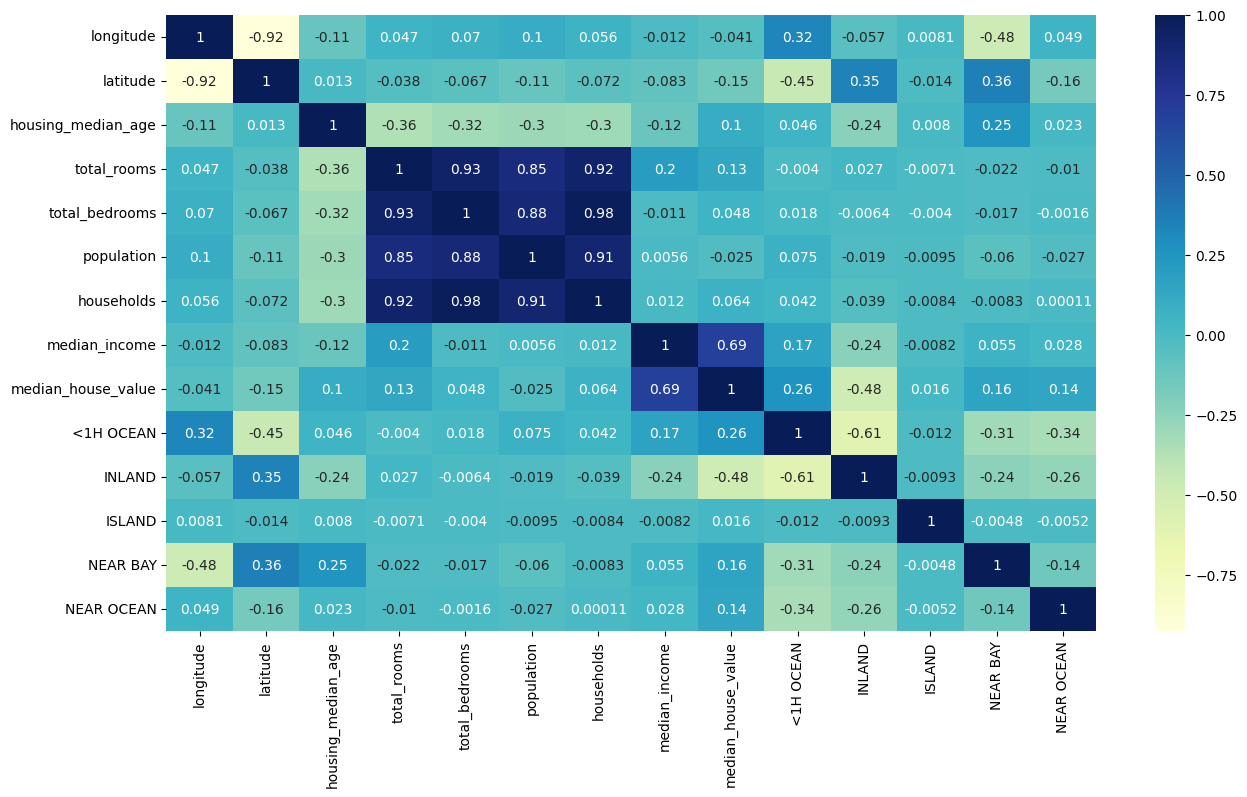

In [40]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

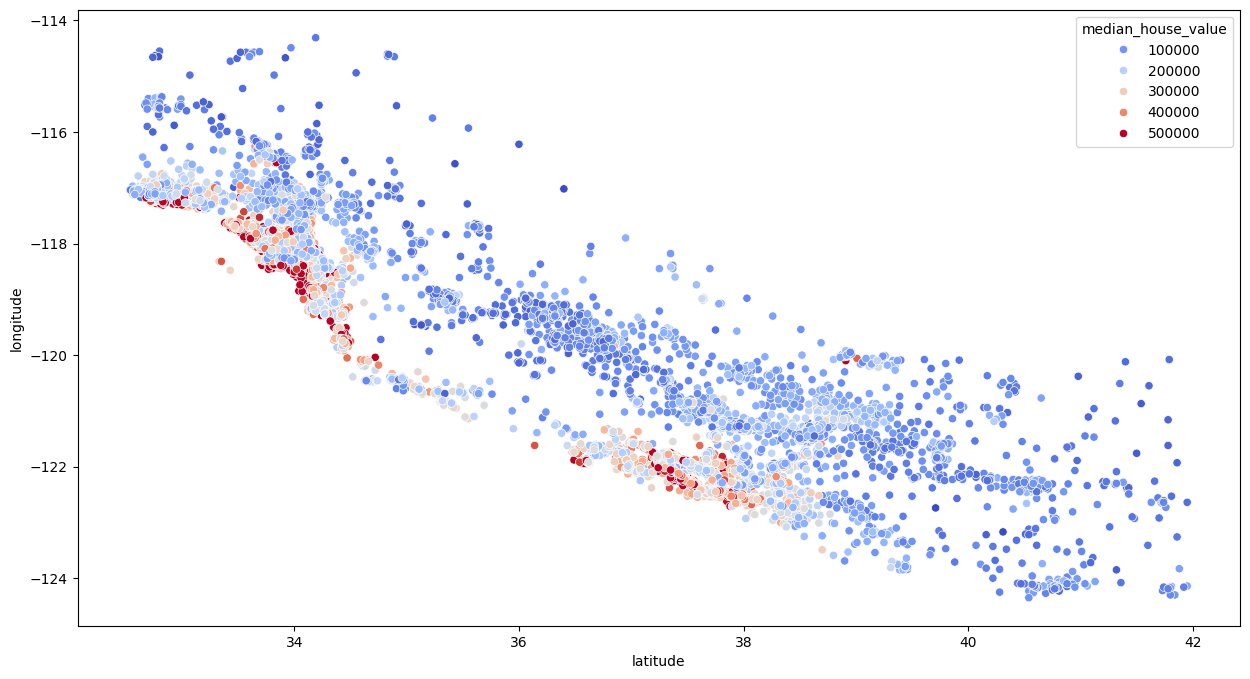

In [41]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [42]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_ratio'] = train_data['total_rooms'] / train_data['households']

<Axes: xlabel='latitude', ylabel='longitude'>

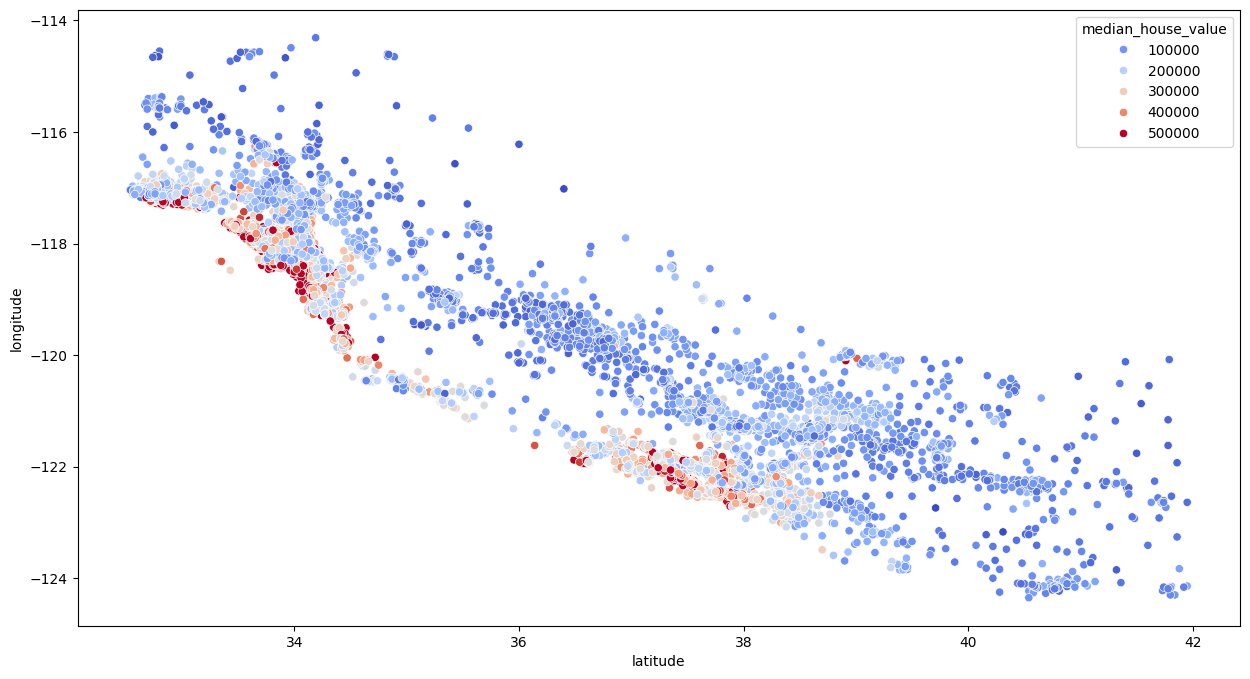

<Axes: >

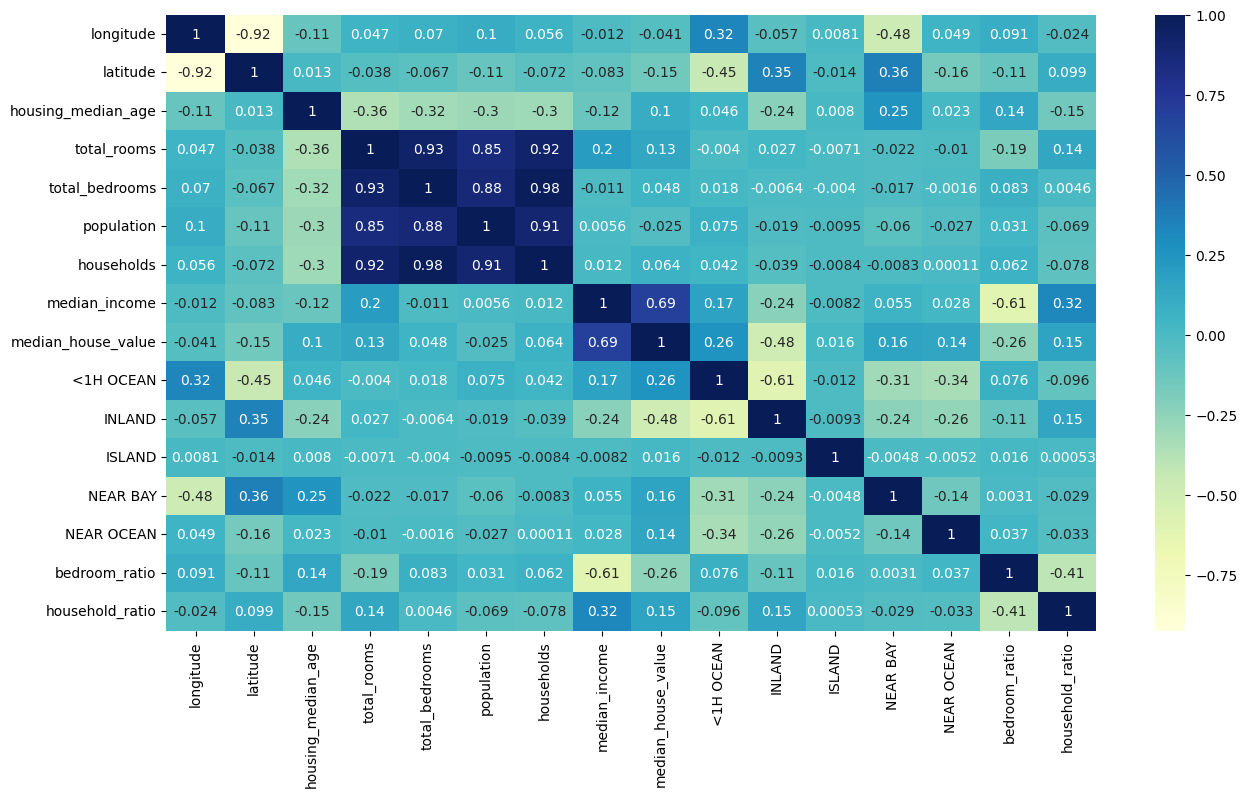

In [44]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [48]:
from sklearn.linear_model import LinearRegression

X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_ratio'] = test_data['total_rooms'] / test_data['households']

X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']


In [46]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_ratio
9295,-122.49,38.00,26.0,3.891820,2.197225,2.995732,2.197225,7.7197,400000.0,0,0,0,1,0,0.564575,1.771244
10986,-117.83,33.75,34.0,7.886457,6.400257,7.297091,6.342121,3.4152,210200.0,1,0,0,0,0,0.811550,1.243505
15710,-122.44,37.79,52.0,7.551712,6.135565,6.723832,6.073045,4.4464,500001.0,0,0,0,1,0,0.812473,1.243480
6945,-118.09,33.99,35.0,7.933080,6.461468,7.562162,6.421622,3.5757,177900.0,1,0,0,0,0,0.814497,1.235370
7796,-118.07,33.90,42.0,6.915723,5.416100,6.655440,5.433722,3.8672,162700.0,1,0,0,0,0,0.783157,1.272741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6381,-118.04,34.18,37.0,8.050384,6.278521,7.107425,6.232448,5.2865,455400.0,0,1,0,0,0,0.779903,1.291689
16165,-122.50,37.77,52.0,7.915713,6.345636,7.180070,6.276643,3.5833,322900.0,0,0,0,1,0,0.801651,1.261138
20559,-121.79,38.67,30.0,7.864420,5.996452,6.889591,6.006353,4.7222,167200.0,0,1,0,0,0,0.762479,1.309350
3192,-119.72,36.34,33.0,7.160846,5.370638,6.364751,5.351858,3.2019,112500.0,0,1,0,0,0,0.750001,1.338011


In [52]:
"""
Le score renvoie le coefficient de détermination 
| R²  | Interprétation                             |
| --- | ------------------------------------------ |
| 1   | Parfait : toutes les prédictions exactes   |
| 0   | Le modèle prédit aussi bien que la moyenne |
| < 0 | Le modèle est pire qu’une simple moyenne   |


0.85 → ton modèle explique 85% de la variance → très bon

0.5 → explique 50% → moyen

-0.1 → prédit moins bien que la moyenne → problème

"""

reg.score(X_test, y_test)

-0.7456691001034725